# Heart Disease Data Analysis and Visualization

## Introduction
Heart disease is one of the leading causes of death worldwide. 
Analyzing medical datasets can help identify patterns and risk 
factors associated with heart disease.

This case study explores a heart disease dataset containing 
medical attributes such as age, cholesterol levels, resting 
blood pressure, and maximum heart rate.

## Research Questions
1. Does age influence the likelihood of heart disease?
2. Is there a relationship between cholesterol levels and heart disease?
3. How does maximum heart rate vary with age?
4. Which medical features have the strongest correlation with heart disease?

## Dataset
Dataset used: UCI Heart Disease Dataset

Columns include:
- age – Age of patient
- sex – Gender (1 = male, 0 = female)
- cp – Chest pain type
- trestbps – Resting blood pressure
- chol – Serum cholesterol
- thalach – Maximum heart rate achieved
- target – Presence of heart disease (1 = yes, 0 = no)

## Dataset Description

This dataset, sourced from Kaggle, contains medical records used to study the presence of heart disease in patients. It includes several health-related attributes such as age, gender, cholesterol level, resting blood pressure, maximum heart rate achieved, and other clinical indicators. By exploring this data, we can analyze how different health factors relate to the likelihood of heart disease and identify potential patterns among patients.

The data required minor preprocessing to handle missing or inconsistent values and to ensure the variables were in a suitable format for analysis and visualization. This preparation allows us to perform accurate exploratory data analysis and generate meaningful insights about heart disease risk factors.

In [10]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [11]:
#Load Dataset
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [12]:
#Explore Dataset
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Matplotlib Visualizations

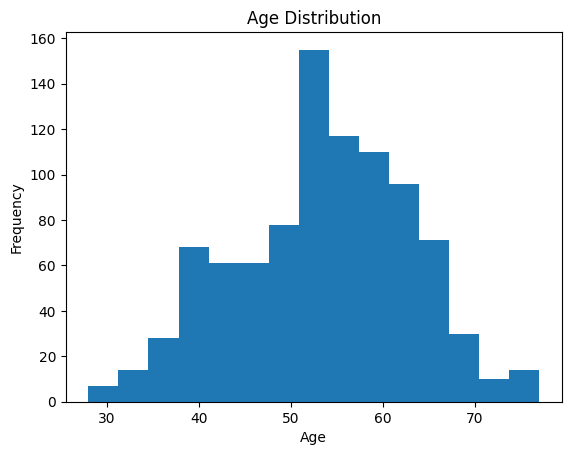

In [13]:
#Age Distribution
plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

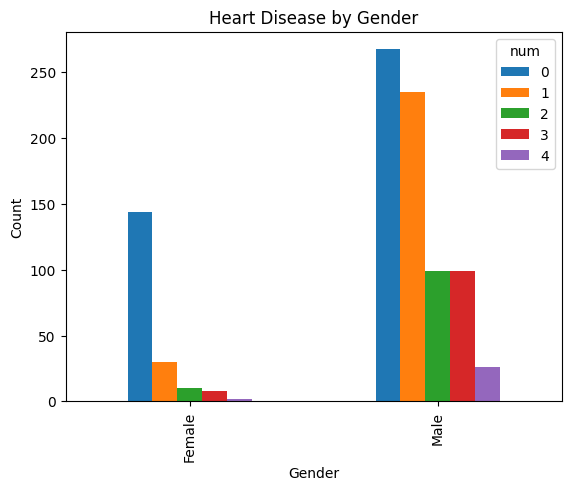

In [5]:
#Heart Disease by Gender
pd.crosstab(df["sex"], df["num"]).plot(kind="bar")

plt.title("Heart Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

**What this shows:**

This bar chart compares the number of heart disease cases between males and females.

**Insight:**

We can observe whether one gender has a higher frequency of heart disease in the dataset. This helps identify potential gender-related health risks.

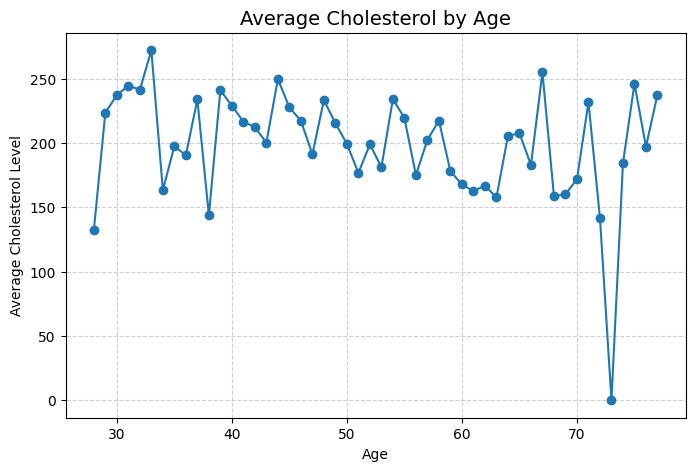

In [27]:
# Line Chart: Average Cholesterol by Age

import matplotlib.pyplot as plt

avg_chol_by_age = df.groupby("age")["chol"].mean()

plt.figure(figsize=(8,5))

plt.plot(avg_chol_by_age.index, avg_chol_by_age.values, marker="o")

plt.title("Average Cholesterol by Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Average Cholesterol Level")

plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig("line_chart.png")

plt.show()

**What this shows:** A line chart displaying the average cholesterol levels for patients across different ages.

**Insight:** The chart helps reveal trends in cholesterol levels as age increases, which may indicate whether cholesterol tends to rise with age among patients in the dataset.

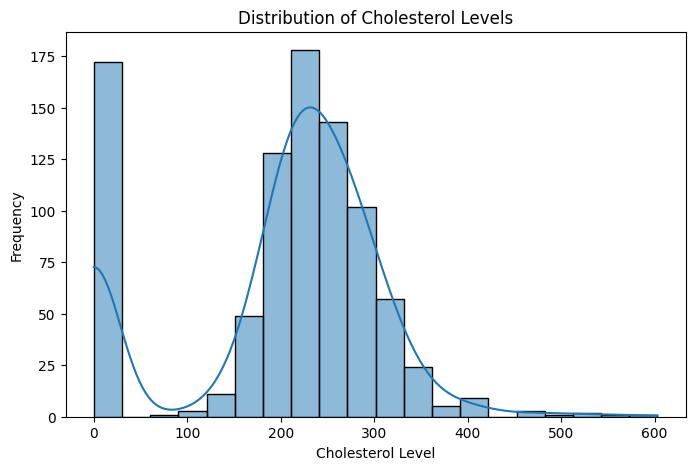

In [ ]:
# Cholesterol Histogram
plt.figure(figsize=(8,5))

sns.histplot(df["chol"], bins=20, kde=True)

plt.title("Distribution of Cholesterol Levels")
plt.xlabel("Cholesterol Level")
plt.ylabel("Frequency")

plt.savefig("histogram.png")

plt.show()

**What this shows:**

This histogram shows the distribution of cholesterol levels among patients.

**Insight:**

Cholesterol is an important risk factor for heart disease. The chart helps us understand whether most patients have normal or elevated cholesterol levels.

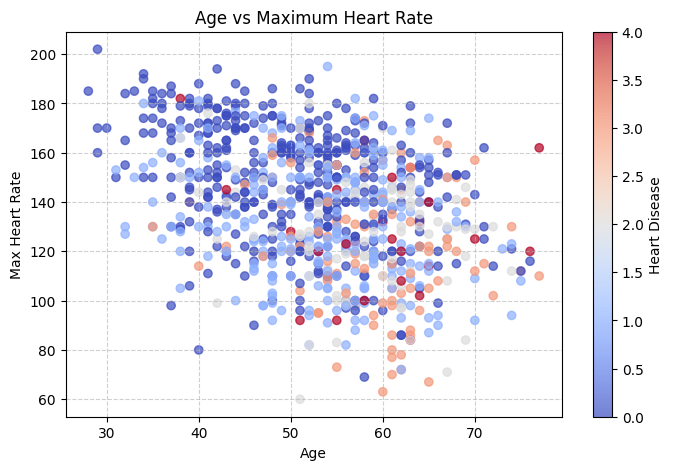

In [17]:
# Scatter Plot: Age vs Max Heart Rate

plt.figure(figsize=(8,5))

plt.scatter(df["age"], df["thalch"], c=df["num"], cmap="coolwarm", alpha=0.7)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")

plt.colorbar(label="Heart Disease")

plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig("scatter_plot.png")

plt.show()

**What this shows:**

This scatter plot visualizes the relationship between patient age and maximum heart rate.

**Insight:**

Typically, maximum heart rate tends to decrease with increasing age. The visualization helps identify whether this trend appears in the dataset.

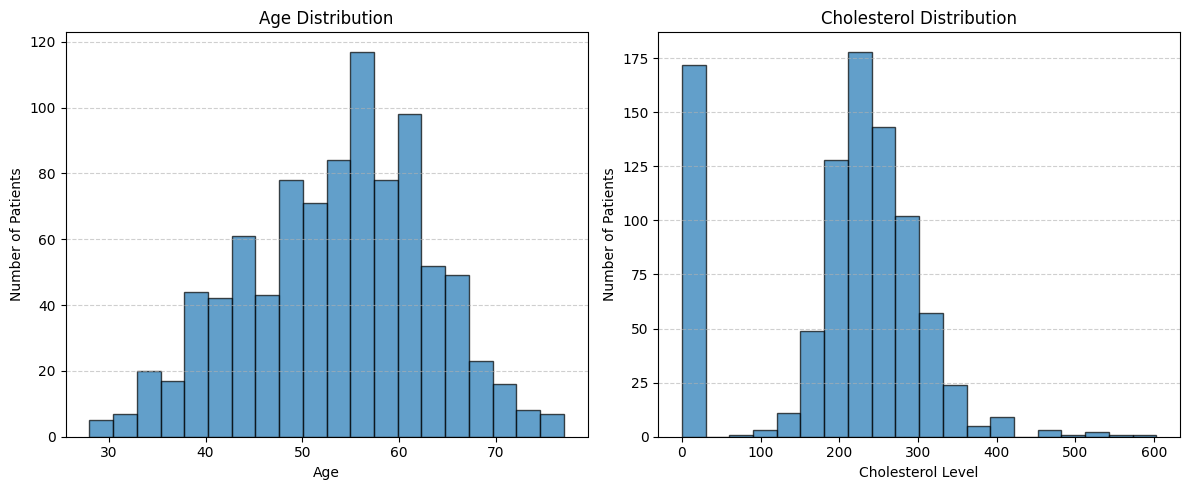

In [18]:
# Subplots: Age and Cholesterol Distribution

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Age Histogram
ax[0].hist(df["age"], bins=20, edgecolor="black", alpha=0.7)
ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Number of Patients")
ax[0].grid(axis="y", linestyle="--", alpha=0.6)

# Cholesterol Histogram
ax[1].hist(df["chol"], bins=20, edgecolor="black", alpha=0.7)
ax[1].set_title("Cholesterol Distribution")
ax[1].set_xlabel("Cholesterol Level")
ax[1].set_ylabel("Number of Patients")
ax[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig("subplots.png")

plt.show()

**What this shows:**

This subplot grid displays two distributions side-by-side:
- Age distribution
- Cholesterol distribution

**Insight:**

By viewing both charts together, we can quickly compare two important health indicators and observe how they vary among patients.

**SEABORN VISUALIZATIONS:**
In this section, we use the Seaborn library to build statistical visualizations. This allows us to easily compare distributions, spot outliers, and identify correlations between the numerical features in our dataset.

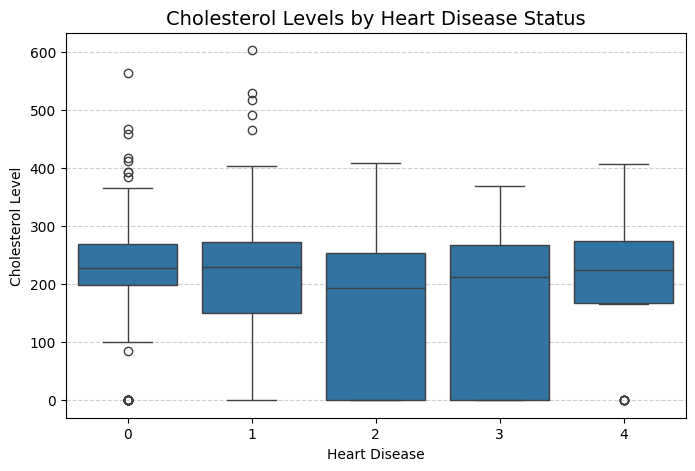

In [25]:
# Boxplot: Cholesterol vs Heart Disease

plt.figure(figsize=(8,5))

sns.boxplot(x="num", y="chol", data=df)

plt.title("Cholesterol Levels by Heart Disease Status", fontsize=14)
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol Level")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig("boxplot.png")

plt.show()


**What this shows:**

This box plot compares cholesterol levels between patients with and without heart disease.

**Insight:**

Box plots help identify differences in distributions and detect outliers. Higher median cholesterol values may indicate increased heart disease risk.

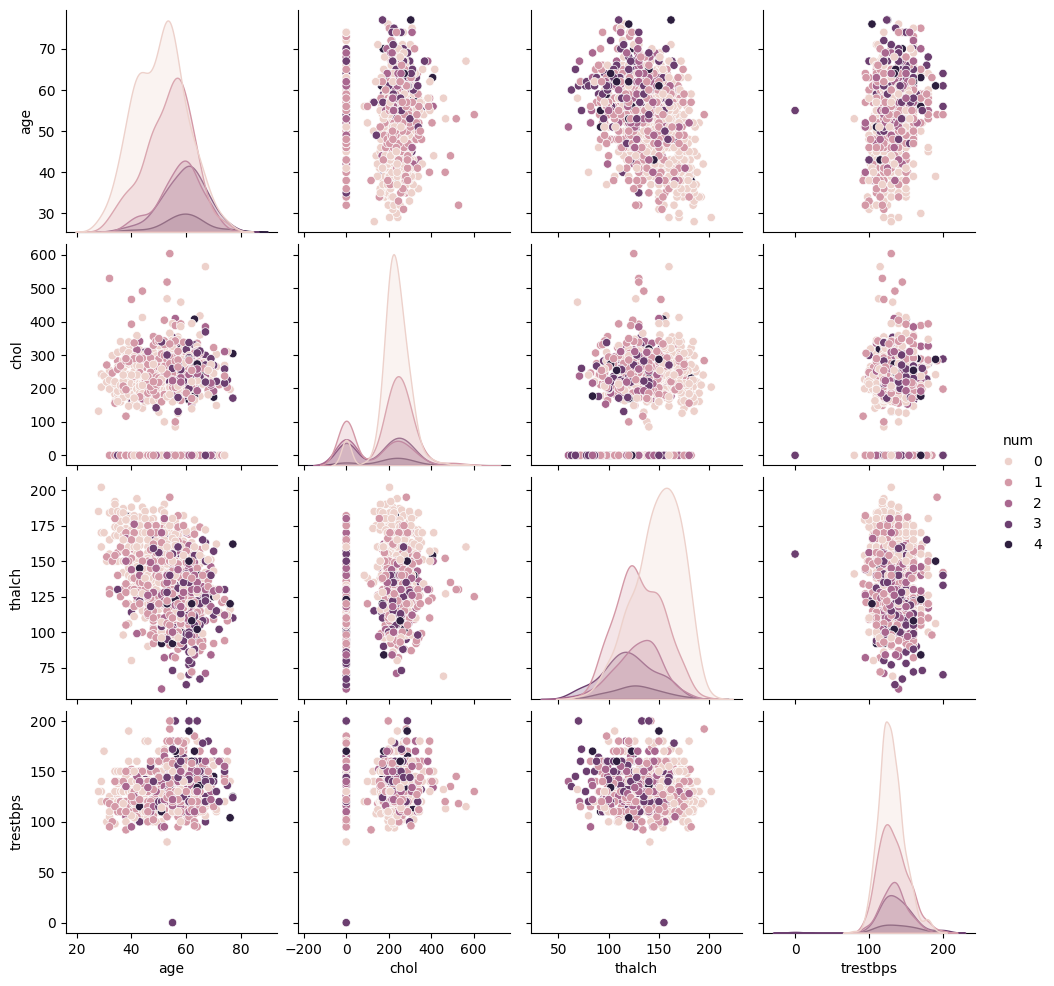

In [20]:
#pairplot
sns.pairplot(df[['age','chol','thalch','trestbps','num']], hue="num")

**What this shows:**

The pair plot displays pairwise relationships between numerical variables such as age, cholesterol, heart rate, and blood pressure.

**Insight:**

This visualization helps reveal patterns, clusters, or correlations between different health metrics and the presence of heart disease.

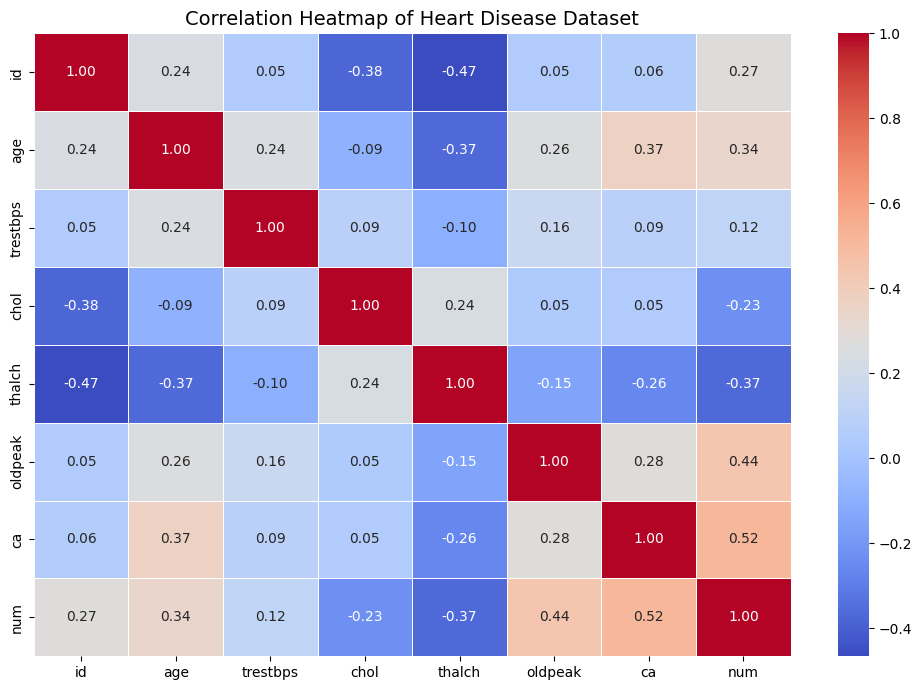

In [26]:
# Correlation Heatmap

plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Heart Disease Dataset", fontsize=14)

plt.tight_layout()

plt.savefig("heatmap.png")

plt.show()

**What this shows:**

This heatmap displays the correlation matrix between numerical variables.

**Insight:**

Correlation values help us identify which variables are strongly related. Variables with stronger correlations with the target variable may be important predictors of heart disease.

Plotly Interactive Chart:

In this final section, we use Plotly Express to create a highly interactive visualization. Unlike static Matplotlib or Seaborn charts, Plotly allows users to zoom in on clusters, click the legend to filter categories, and hover over individual data points to reveal specific details about a title.

In [11]:
pio.renderers.default = "browser"  
fig = px.scatter(
    df,
    x="age",
    y="chol",
    color="num",
    title="Age vs Cholesterol",
    labels={"num": "Heart Disease"}
)

fig.show() 
fig.write_image("plotly_chart.png") 

**What this shows:** An interactive scatter plot comparing patients’ age and their cholesterol levels, with points color-coded by whether the patient has heart disease or not.



**Insight:** The visualization helps reveal patterns between age and cholesterol levels and how they relate to heart disease. Clusters of patients with heart disease may appear in certain age ranges or cholesterol levels, suggesting possible relationships between these health factors.

## Executive Summary & Final Insights

Based on the visualizations generated in this analysis, several important observations can be made:

1. Older individuals appear to have a higher likelihood of heart disease.
2. Cholesterol levels vary widely among patients and may influence heart disease risk.
3. Certain health indicators such as blood pressure and heart rate show relationships with heart disease outcomes.
4. Correlation analysis suggests that multiple clinical factors contribute to heart disease risk rather than a single variable.

These insights highlight the importance of monitoring multiple health indicators when assessing cardiovascular risk.

## Conclusion

The analysis of the heart disease dataset provides valuable insights into how various health factors relate to cardiovascular risk.

Visualizations using Matplotlib, Seaborn, and Plotly helped uncover patterns in age distribution, cholesterol levels, and heart rate relationships. These findings demonstrate the usefulness of data visualization in understanding complex medical datasets.

Overall, this case study shows how exploratory data analysis can support better understanding of health risks and potentially guide medical research and decision-making.